# DMRG Ground State Searches in 1D Systems with Criticality

<div style="text-align: right; font-style: italic; color: #6b7280; margin: 8px 0; font-size: 0.95em;">
Authored by <strong>Gauthameshwar S.</strong>
</div>

<div style="
    border: 1px solid #3b82f6;
    border-left: 5px solid #3b82f6;
    padding: 12px 14px;
    border-radius: 8px;
    margin: 12px 0;
    box-shadow: 0 1px 2px rgba(0,0,0,0.06);
">
    <div style="font-weight: 700; margin-bottom: 6px;">TL;DR</div>
    <div>
        When does DMRG work extremely well, and when does it struggle for quantum many-body systems?
        This notebook answers that question through a concrete, pedagogical example: the
        <strong>transverse field Ising model (TFI)</strong> in one dimension.
        The computational difficulty of DMRG is governed by the entanglement structure and correlation
        lengths in your system’s ground state.
    </div>
</div>

### What you will do here
- Define a quantum state as an MPS using ITensorMPS. 
- Build the 1D TFI Hamiltonian as an MPO using ITensorMPS (`OpSum` → `MPO`).
- Run DMRG across a range of field strengths $h/J$ and track convergence diagnostics.
- Connect “DMRG difficulty” to entanglement: compare gapped vs. near-critical behavior and how this impacts the required MPS bond dimension.
- Compute the order parameter $m_x = \frac{1}{N}\sum_i\langle \sigma^x_i \rangle$ and visualize the phase transition (optional).



<div style="
    border: 1px solid #3bf689;
    border-left: 5px solid #3bf689;
    padding: 12px 14px;
    border-radius: 8px;
    margin: 12px 0;
    box-shadow: 0 1px 2px rgba(0,0,0,0.06);
">
    <div style="font-weight: 700; margin-bottom: 6px;">Tip</div>
    <div>
        <p>If you are new to coding in ITensorMPS and ITensors, do look at the official docs of them to get an idea of how you call certain functions.</p>
        <ul style="margin-top: 8px;">
            <li>Official Docs for <a href="https://itensor.github.io/ITensors.jl/stable/index.html">ITensors.jl</a></li>
            <li>Official Docs for <a href="https://itensor.github.io/ITensorMPS.jl/stable/index.html">ITensorMPS.jl</a></li>
        </ul>
        <p style="margin-top: 8px;">
            I suggested at this stage, you do not use Claude, GPTs, or "vibe-code" this notebook unless you have a good understanding of how these codes work.
        </p>
    </div>
</div>

## The model: 1D Transverse-Field Ising Model (TFI)
We consider an one-dimensional TFI chain with open boundary conditions following the Hamiltonian
$$
\begin{equation}
H = - J \sum_{j=1}^{N-1} \sigma^x_j \sigma^x_{j+1} - h \sum_{i=1}^{N} \sigma^z_i
\end{equation}
$$
where $J$ is the coupling strength between neighboring spins, $h$ is the magnitude of the transverse-field, and $\sigma^{x/z}_i$ are the Pauli spin operators acting on site $i$. 

### The Phases of the TFI Model

The TFIM exhibits three distinct regimes as the transverse field $h$ is varied.
- **Ferromagnetic phase ($h/J < 1$)**  
  The system is gapped, exhibits spontaneous $\mathbb{Z}_2$ symmetry breaking, and has a finite correlation length.  
  In the extreme limit $h/J \ll 1$, the Hamiltonian reduces to the classical Ising model and the two degenerate ground states are simple product states,
  $$
  |\psi_{FM}\rangle = |\rightarrow\rightarrow\cdots\rightarrow\rangle, \qquad
  |\leftarrow\leftarrow\cdots\leftarrow\rangle .
  $$
  These states have *zero entanglement*. 

- **Critical point ($h/J = 1$)**  
  The system becomes gapless, the correlation length diverges, and the low-energy physics is described by a $(1+1)\textrm{D}$-dimensional conformal field theory in the Ising universality class.

- **Paramagnetic phase ($h/J > 1$)**  
  The system is again gapped and disordered, with a finite correlation length.  
  In the opposite extreme limit $h/J \gg 1$, the ground state is a trivial paramagnet polarized along the $z$ direction,
  $$
  |\psi_{PM}\rangle = |\uparrow\uparrow\cdots\uparrow\rangle ,
  $$
  which is again a product state with vanishing entanglement. 

A convenient order parameter for this phase transition is the transverse magnetisation
$$
m_x = \frac{1}{N} \sum_i \langle \sigma_i^x \rangle ,
$$
which serves as the order parameter. In the thermodynamic limit, $m_x \neq 0$ in the ferromagnetic phase, $m_x = 0$ in the paramagnetic phase, and the transition between them occurs at $h = 1$.

<figure style="text-align:center; margin: 16px 0;">
    <img src="figures/TFI_magnetisation_vs_h.svg" alt="TFI phase diagram" style="max-width: 90%; height: auto;">
    <figcaption style="font-style: italic; color: #6b7280; margin-top: 8px;">
        Phase transition of a 500-site 1D TFI model, showing ferromagnetic, critical, and paramagnetic regimes.
    </figcaption>
</figure>

---

## Entanglement Scaling affects the MPS Representability

Entanglement entropy provides the crucial link between the physical properties of a quantum phase and the efficiency of tensor-network methods such as DMRG. This is because the bond dimension $\chi$ required to accurately represent a quantum state as an MPS is directly related to the entanglement entropy $S$ across bipartitions of the system as
$$
S \lesssim \log \chi .
$$

Thus, the scaling of $S$ with system size directly determines how $\chi$ must scale in order to faithfully approximate the ground state.

However, entanglement scaling itself is not fundamental — it is controlled by the **correlation length** $\xi$ of the system, which in turn is determined by the presence or absence of a **spectral gap**.

---

### Area Law for Gapped Phases

An *area law* states that the entanglement entropy of a region scales with the size of its boundary rather than its volume:
$$
S(A) \sim |\partial A| .
$$

In **1D**, a bipartition has a constant number of boundary points, so
$$
S = \mathcal{O}(1).
$$

Area-law behavior is a generic property of ground states of **local, gapped Hamiltonians**.  
The physical reason is that a finite spectral gap $\Delta > 0$ implies a **finite correlation length**
$$
\xi \sim \Delta^{-1},
$$
so correlations decay exponentially beyond the scale $\xi$. As a result, only degrees of freedom within a distance $\sim\xi$ of the boundary between two subsystems contribute appreciably to entanglement.

In contrast, a **volume law**
$$
S(A) \sim |A|
$$
occurs in highly excited states, thermal states, and generic random pure states. Volume-law entanglement requires an exponentially large bond dimension $\chi \sim e^{|A|}$ and is fundamentally incompatible with efficient MPS representations.

---

### Logarithmic Scaling at Criticality

At a one-dimensional quantum critical point, the spectral gap closes,
$$
\Delta \to 0 \quad \Rightarrow \quad \xi \to \infty ,
$$
and correlations extend over all length scales. In this case, the area law is violated logarithmically.

For a system described by a $(1+1)\textrm{D}$ conformal field theory (CFT), the bipartite entanglement entropy of an interval of length $\ell$ scales as
$$
S(\ell) = \frac{c}{6} \log \ell + \text{const}.
$$
For the transverse-field Ising model, the critical point at $h/J = 1$ is described by the Ising CFT with
$$
c = \frac{1}{2}.
$$

This logarithmic growth implies that the entanglement entropy across the center of a chain increases with system size. Consequently, the bond dimension required for an accurate MPS representation must also grow with $L$, leading to a polynomial (rather than constant) computational cost.

---

## Spectral Gap, Correlation Length, Entanglement, and Bond Dimension

A central organizing principle for understanding the performance of DMRG is the presence or absence of a **spectral gap**. The gap controls the correlation length, which controls entanglement scaling, which in turn determines MPS representability.

These relationships can be summarized as follows:

| Phase | Spectral gap $\Delta$ | Correlation length $\xi$ | Entanglement entropy | Bond dimension scaling | DMRG behavior |
|:-----:|:---------------------:|:------------------------:|:--------------------:|:----------------------:|:-------------:|
| Ferromagnetic ($h < 1$) | Finite | Finite ($\xi \sim \Delta^{-1}$) | $S=\mathcal{O}(1)$ | $\chi=\mathcal{O}(1)$ | Very efficient |
| Critical ($h = 1$) | Zero | Divergent | $S \sim \log L$ | $\chi \sim L^\alpha$ | Slower, polynomial cost |
| Paramagnetic ($h > 1$) | Finite | Finite ($\xi \sim \Delta^{-1}$) | $S=\mathcal{O}(1)$ | $\chi=\mathcal{O}(1)$ | Very efficient |

This table encapsulates the core message of the tutorial:

**spectral gap $\;\Rightarrow\;$ finite correlation length $\;\Rightarrow\;$ area-law entanglement $\;\Rightarrow\;$ bounded bond dimension and efficient DMRG**,  
while  
**gapless criticality $\;\Rightarrow\;$ divergent correlations $\;\Rightarrow\;$ logarithmic entanglement growth $\;\Rightarrow\;$ increasing bond dimension and slower DMRG.**

---


In [1]:
using ITensors, ITensorMPS

# Find the ground state energy of a TFI model
N = 15
J = 1.0
h = 1.4

sites = siteinds("S=1/2", N)

# all up state |↑↑...↑>
psi0_it = MPS(sites, ["Up" for i in 1:N])

# H = -J Σ⟨ij⟩ Sx_i Sx_j - h_z Σ Sz_i
os = OpSum()
for j in 1:N-1
    os += -4J, "Sx", j, "Sx", j+1
end
for i in 1:N
    os += -2h, "Sz", i
end
H_it = MPO(os, sites)

energy_it, psi_it = dmrg(H_it, psi0_it; nsweeps=10, maxdim=200, cutoff=1e-10, outputlevel=0)
energy_it


-23.577015204610866

Good job running your DMRG algorithm for a single system! Now we can look at how the bond dimension scales for a TFI model with $h = 0.5, 1.0, 2.0$. Note that the system is critical at $h=1.0$. 

<div style="border: 1px solid #f97316; border-left: 5px solid #f97316; padding: 12px 14px; border-radius: 8px; margin: 12px 0; box-shadow: 0 1px 2px rgba(0,0,0,0.06);">
    <div style="font-weight:700; margin-bottom:6px;">Implementation note (ITensors convention).</div>
    <div>
        In the code we use the spin operators $S^\alpha = \sigma^\alpha/2$. So in the MPO terms you must use factors like $-4J$ for $S^x_i S^x_j$ and $-2h_z$ for $S^z_i$.
    </div>
</div>


In [2]:
# Get the max bond dimension of each ground state for the TFI model as we vary h/J
using Printf

hs = [0.5, 1.0, 2.0]
Ns = 2 .^ (2:10)

max_bond_dims = Dict{Float64, Vector{Int}}()
for h in hs
    max_bonds_h = Int[]
    for N in Ns
        sites = siteinds("S=1/2", N)
        psi0_it = MPS(sites, ["Up" for i in 1:N])
        # H = - Σ⟨ij⟩ Sx_i Sx_j - h_z Σ Sz_i
        os = OpSum()
        for j in 1:N-1
            os += -4, "Sx", j, "Sx", j+1
        end
        for i in 1:N
            os += -2h, "Sz", i
        end
        H_it = MPO(os, sites)
        energy_it, psi_it = dmrg(H_it, psi0_it; nsweeps=15, maxdim=200, cutoff=1e-12, outputlevel=0)
        bond_dims = [dim(linkind(psi_it, i)) for i in 1:length(psi_it)-1]
        push!(max_bonds_h, maximum(bond_dims))
    end
    max_bond_dims[h] = max_bonds_h
end


In [3]:
# Print neat tables
using Printf

function tabulate(Ns, hs, max_bond_dims)
    function _center_field(x, w::Int)
        s = string(x)
        n = length(s)
        if n ≥ w
            return w > 0 ? s[1:w] : ""
        end
        pad = w - n
        left = pad ÷ 2
        right = pad - left
        return " "^left * s * " "^right
    end

    headers = ["L", ["bond dim (h/J=$(h))" for h in hs]...]
    widths = [6; fill(22, length(hs))...]
    total_width = sum(widths)

    println("\n", "-"^total_width)
    for (h, w) in zip(headers, widths)
        print(_center_field(h, w))
    end
    println()
    println("-"^total_width)

    for (i, N) in enumerate(Ns)
        print(_center_field(N, widths[1]))
        for (j, h) in enumerate(hs)
            print(_center_field(max_bond_dims[h][i], widths[j+1]))
        end
        println()
    end
    println("-"^total_width)
end

tabulate(Ns, hs, max_bond_dims)


------------------------------------------------------------------------
  L     bond dim (h/J=0.5)    bond dim (h/J=1.0)    bond dim (h/J=2.0)  
------------------------------------------------------------------------
  4             4                     4                     4           
  8             8                     9                     6           
  16            10                    13                    6           
  32            10                    17                    6           
  64            10                    25                    6           
 128            10                    33                    6           
 256            10                    43                    6           
 512            10                    59                    6           
 1024           10                    68                    6           
------------------------------------------------------------------------


Since we expect the bond dimensions at criticality to scale as a polynomial power in $L$, its log-log plot must be a linear line. 

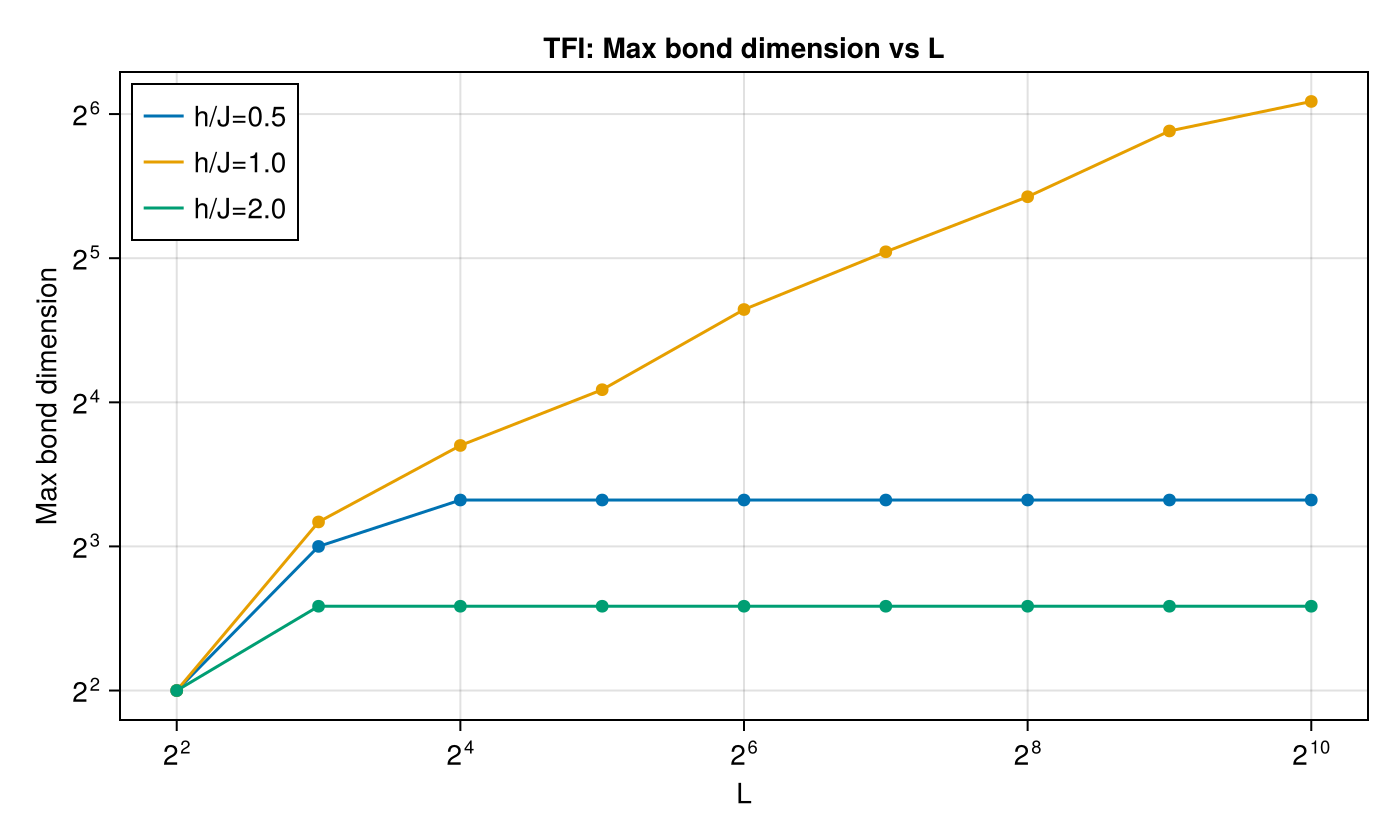

In [4]:
# CairoMakie plot: max bond dimension vs L (Uncomment to use)
using CairoMakie

fig = Figure(;size=(700, 420))
ax = Axis(fig[1, 1], 
    title="TFI: Max bond dimension vs L", 
    xlabel="L", 
    ylabel="Max bond dimension", 
    xscale=log2, 
    yscale=log2, 
)
for h in hs
    lines!(ax, Ns, max_bond_dims[h], label="h/J=$(h)")
    scatter!(ax, Ns, max_bond_dims[h])
end
xs = [minimum(Ns), maximum(Ns)]
axislegend(ax, position=:lt)
fig

In [5]:
# OPTIONAL: Simulate the phase transition of our model by computing the magnetisation vs order parameter h
N = 500
hs = range(0.0, stop=2.0, length=60)

magnetisations = Float64[]

for h in hs
    sites = siteinds("S=1/2", N)
    # Initial state |→→→...→→→⟩
    psi0_it = MPS(sites)
    for i in 1:N
        psi0_it[i] = state(sites[i], "X+")
    end
    # H = -J Σ⟨ij⟩ Sx_i Sx_j - h_z Σ Sz_i
    os = OpSum()
    for j in 1:N-1
        os += -4J, "Sx", j, "Sx", j+1
    end
    for i in 1:N
        os += -2h, "Sz", i
    end
    H_it = MPO(os, sites)
    energy_it, psi_it = dmrg(H_it, psi0_it; nsweeps=10, maxdim=200, cutoff=1e-10, outputlevel=0)
    mag = 2sum(expect(psi_it, "Sx")) / N
    push!(magnetisations, mag)
end

In [6]:
display(magnetisations)

60-element Vector{Float64}:
  1.0000000000000002
  0.9998545653916149
  0.9994173700139889
  0.9986857196162074
  0.9976550575253791
  0.9963188620802592
  0.9946684960808835
  0.9926929948014126
  0.9903788067574407
  0.9877094223197709
  0.9846649233615136
  0.9812213894216796
  0.9773501312731385
  ⋮
 -8.038760814388866e-15
  1.1833568793631527e-14
  4.0044979865551184e-15
  1.9112940753238274e-15
 -7.501002950132589e-16
 -7.641346469761939e-15
  6.60669295743355e-15
 -2.0056505943575505e-15
 -3.79484086372417e-15
 -6.304762983498421e-16
 -4.936899909980973e-15
 -1.8243839630652145e-15

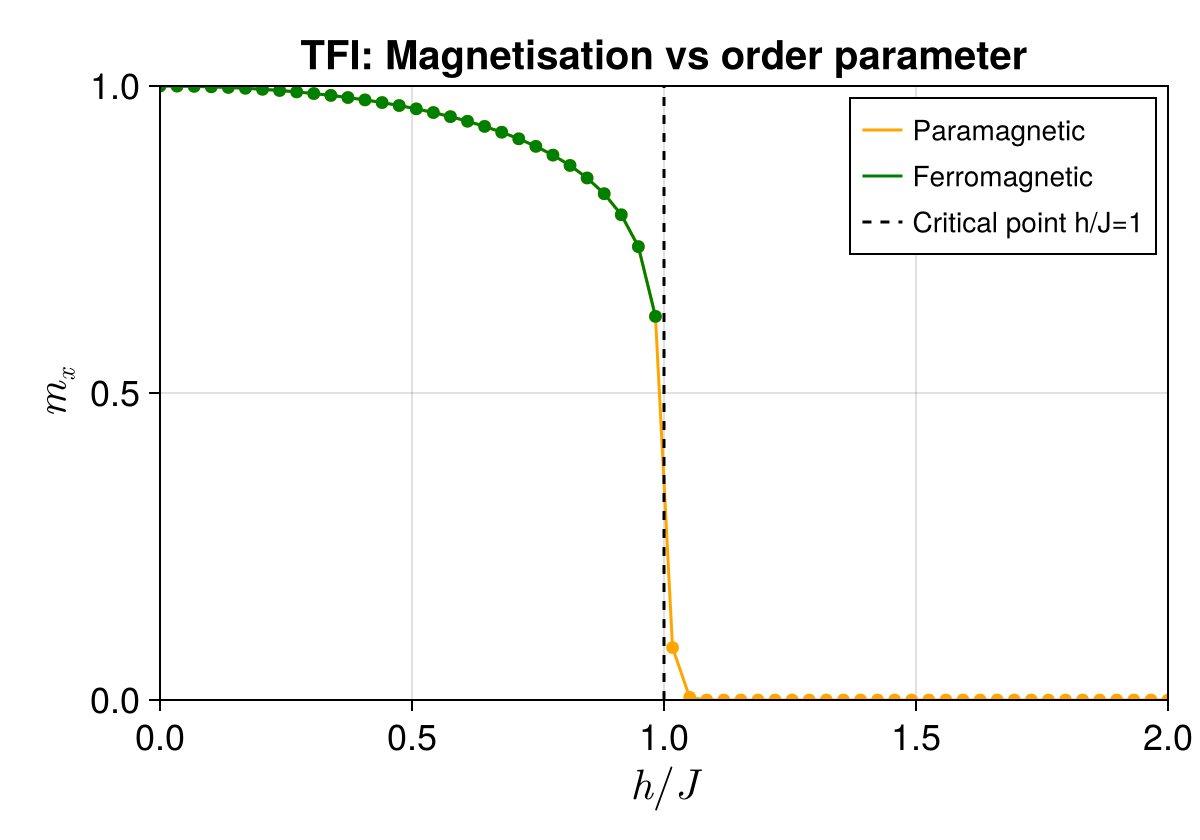

In [7]:
# CairoMakie plot of magnetisation vs h (Uncomment to use)
fig = Figure(;size=(600, 420))
ax = Axis(fig[1, 1], 
    xlabel=L"h/J", 
    ylabel=L"m_x", 
    limits=(0.0, 2.0, 0.0, 1.0), 
    title="TFI: Magnetisation vs order parameter", 
    titlesize=20,
    xlabelsize=22,
    ylabelsize=22,
    xticklabelsize=18,
    yticklabelsize=18,
)
# The paramagnetic branch
lines!(ax, hs, magnetisations, label="Paramagnetic", color=:orange)
scatter!(ax, hs, magnetisations, color=:orange)
# The ferromagnetic branch overlaying the paramagnetic branch
ferro_hs = hs[hs .< 1.0]
ferro_mags = magnetisations[hs .< 1.0]
lines!(ax, ferro_hs, ferro_mags, label="Ferromagnetic", color=:green)
scatter!(ax, ferro_hs, ferro_mags, color=:green)

lines!(ax, [1,1], [0,1], linestyle=:dash, color=:black, label="Critical point h/J=1")
axislegend(ax, position=:rt)
fig